# Config

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

import os
from dotenv import load_dotenv

from entsoe import EntsoePandasClient

load_dotenv()

# ENTSOE Token
entsoe_token = os.getenv("ENTSOE_API_TOKEN")

# ENTSOE Client
entsoe_client = EntsoePandasClient(api_key=entsoe_token)

# Fetch Generation by Fuel

In [2]:
# Location
country_capital = "Madrid"
country_code = "ES"


# Period
today = pd.Timestamp.now(
    tz=f"Europe/{country_capital}"
).normalize()

yesterday=(pd.Timestamp.now(tz=f"Europe/{country_capital}")
    .normalize()
    - pd.Timedelta(days=1)
)
last_week=(pd.Timestamp.now(tz=f"Europe/{country_capital}")
    .normalize()
    - pd.Timedelta(days=7)
)

tomorrow =(pd.Timestamp.now(tz=f"Europe/{country_capital}")
    .normalize()
    + pd.Timedelta(days=1)
)


start=last_week
end=today


# ENTSOE Client
df = entsoe_client.query_generation(
    country_code=country_code,
    start=last_week,
    end=today)

# EDA

In [3]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 671 entries, 2026-08-30 00:00:00+02:00 to 2026-09-05 23:45:00+02:00
Data columns (total 23 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   (Biomass, Actual Aggregated)                          671 non-null    float64
 1   (Energy storage, Actual Aggregated)                   671 non-null    float64
 2   (Energy storage, Actual Consumption)                  671 non-null    float64
 3   (Fossil Brown coal/Lignite, Actual Aggregated)        671 non-null    float64
 4   (Fossil Coal-derived gas, Actual Aggregated)          671 non-null    float64
 5   (Fossil Gas, Actual Aggregated)                       671 non-null    float64
 6   (Fossil Hard coal, Actual Aggregated)                 671 non-null    float64
 7   (Fossil Oil, Actual Aggregated)                       671 non-null    float64
 8   (Fossil Oil shale, Act

In [4]:
df.head()

Biomass    Energy storage  \
                          Actual Aggregated Actual Aggregated   
2026-08-30 00:00:00+02:00             496.0               0.0   
2026-08-30 00:15:00+02:00             496.0               0.0   
2026-08-30 00:30:00+02:00             496.0               0.0   
2026-08-30 00:45:00+02:00             500.0               0.0   
2026-08-30 01:00:00+02:00             504.0               0.0   

                                             Fossil Brown coal/Lignite  \
                          Actual Consumption         Actual Aggregated   
2026-08-30 00:00:00+02:00                0.0                       0.0   
2026-08-30 00:15:00+02:00                0.0                       0.0   
2026-08-30 00:30:00+02:00                0.0                       0.0   
2026-08-30 00:45:00+02:00                0.0                       0.0   
2026-08-30 01:00:00+02:00                0.0                       0.0   

                          Fossil Coal-derived gas        Fossil Gas  \
                                Actual Aggregated Actual Aggregated   
2026-08-30 00:00:00+02:00                     0.0            7212.0   
2026-08-30 00:15:00+02:00                     0.0            6676.0   
2026-08-30 00:30:00+02:00                     0.0            6740.0   
2026-08-30 00:45:00+02:00                     0.0            6740.0   
2026-08-30 01:00:00+02:00                     0.0            6460.0   

                           Fossil Hard coal        Fossil Oil  \
                          Actual Aggregated Actual Aggregated   
2026-08-30 00:00:00+02:00               0.0              24.0   
2026-08-30 00:15:00+02:00               0.0              24.0   
2026-08-30 00:30:00+02:00               0.0              24.0   
2026-08-30 00:45:00+02:00               0.0              20.0   
2026-08-30 01:00:00+02:00               0.0              20.0   

                           Fossil Oil shale       Fossil Peat  ...  \
                          Actual Aggregated Actual Aggregated  ...   
2026-08-30 00:00:00+02:00               0.0               0.0  ...   
2026-08-30 00:15:00+02:00               0.0               0.0  ...   
2026-08-30 00:30:00+02:00               0.0               0.0  ...   
2026-08-30 00:45:00+02:00               0.0               0.0  ...   
2026-08-30 01:00:00+02:00               0.0               0.0  ...   

                          Hydro Run-of-river and poundage  \
                                        Actual Aggregated   
2026-08-30 00:00:00+02:00                           556.0   
2026-08-30 00:15:00+02:00                           556.0   
2026-08-30 00:30:00+02:00                           580.0   
2026-08-30 00:45:00+02:00                           580.0   
2026-08-30 01:00:00+02:00                           572.0   

                          Hydro Water Reservoir            Marine  \
                              Actual Aggregated Actual Aggregated   
2026-08-30 00:00:00+02:00                1424.0               0.0   
2026-08-30 00:15:00+02:00                1544.0               0.0   
2026-08-30 00:30:00+02:00                1688.0               0.0   
2026-08-30 00:45:00+02:00                1760.0               0.0   
2026-08-30 01:00:00+02:00                1636.0               0.0   

                                    Nuclear             Other  \
                          Actual Aggregated Actual Aggregated   
2026-08-30 00:00:00+02:00            6988.0              12.0   
2026-08-30 00:15:00+02:00            6988.0              12.0   
2026-08-30 00:30:00+02:00            6988.0              12.0   
2026-08-30 00:45:00+02:00            6988.0              12.0   
2026-08-30 01:00:00+02:00            6988.0              12.0   

                            Other renewable             Solar  \
                          Actual Aggregated Actual Aggregated   
2026-08-30 00:00:00+02:00              72.0             608.0   
2026-08-30 00:15:00+02:00              72.0          

In [5]:
df.columns

MultiIndex([(                        'Biomass',  'Actual Aggregated'),
            (                 'Energy storage',  'Actual Aggregated'),
            (                 'Energy storage', 'Actual Consumption'),
            (      'Fossil Brown coal/Lignite',  'Actual Aggregated'),
            (        'Fossil Coal-derived gas',  'Actual Aggregated'),
            (                     'Fossil Gas',  'Actual Aggregated'),
            (               'Fossil Hard coal',  'Actual Aggregated'),
            (                     'Fossil Oil',  'Actual Aggregated'),
            (               'Fossil Oil shale',  'Actual Aggregated'),
            (                    'Fossil Peat',  'Actual Aggregated'),
            (                     'Geothermal',  'Actual Aggregated'),
            (           'Hydro Pumped Storage',  'Actual Aggregated'),
            (           'Hydro Pumped Storage', 'Actual Consumption'),
            ('Hydro Run-of-river and poundage',  'Actual Aggregated'),
      

In [6]:
df.describe().T.round(2)

count      mean       std  \
Biomass                         Actual Aggregated   671.0    410.73     44.44   
Energy storage                  Actual Aggregated   671.0      1.51      4.68   
                                Actual Consumption  671.0      1.34      5.10   
Fossil Brown coal/Lignite       Actual Aggregated   671.0      0.00      0.00   
Fossil Coal-derived gas         Actual Aggregated   671.0      0.00      0.00   
Fossil Gas                      Actual Aggregated   671.0   7769.64   4155.53   
Fossil Hard coal                Actual Aggregated   671.0     96.51    103.41   
Fossil Oil                      Actual Aggregated   671.0     20.48      5.53   
Fossil Oil shale                Actual Aggregated   671.0      0.00      0.00   
Fossil Peat                     Actual Aggregated   671.0      0.00      0.00   
Geothermal                      Actual Aggregated   671.0      0.00      0.00   
Hydro Pumped Storage            Actual Aggregated   671.0   1197.79    897.03   
                                Actual Consumption  671.0    979.39   1330.08   
Hydro Run-of-river and poundage Actual Aggregated   671.0    470.59     73.66   
Hydro Water Reservoir           Actual Aggregated   671.0   1374.50   1013.53   
Marine                          Actual Aggregated   671.0      0.00      0.00   
Nuclear                         Actual Aggregated   671.0   6665.38    497.85   
Other                           Actual Aggregated   671.0     14.07      2.23   
Other renewable                 Actual Aggregated   671.0     65.31      5.05   
Solar                           Actual Aggregated   671.0  10348.45  11038.60   
Waste                           Actual Aggregated   671.0    235.80     17.88   
Wind Offshore                   Actual Aggregated   671.0      0.00      0.00   
Wind Onshore                    Actual Aggregated   671.0   3280.07   1819.11   

                                                       min     25%     50%  \
Biomass                         Actual Aggregated    276.0   384.0   412.0   
Energy storage                  Actual Aggregated      0.0     0.0     0.0   
                                Actual Consumption     0.0     0.0     0.0   
Fossil Brown coal/Lignite       Actual Aggregated      0.0     0.0     0.0   
Fossil Coal-derived gas         Actual Aggregated      0.0     0.0     0.0   
Fossil Gas                      Actual Aggregated   2448.0  3934.0  6504.0   
Fossil Hard coal                Actual Aggregated      0.0     0.0     0.0   
Fossil Oil                      Actual Aggregated     12.0    16.0    20.0   
Fossil Oil shale                Actual Aggregated      0.0     0.0     0.0   
Fossil Peat                     Actual Aggregated      0.0     0.0     0.0   
Geothermal                      Actual Aggregated      0.0     0.0     0.0   
Hydro Pumped Storage            Actual Aggregated      0.0   304.0  1232.0   
                                Actual Consumption     0.0     0.0    64.0   
Hydro Run-of-river and poundage Actual Aggregated    332.0   404.0   464.0   
Hydro Water Reservoir           Actual Aggregated    204.0   626.0  1176.0   
Marine                          Actual Aggregated      0.0     0.0     0.0   
Nuclear                         Actual Aggregated   5400.0  6648.0  6948.0   
Other                           Actual Aggregated      8.0    12.0    12.0   
Other renewable                 Actual Aggregated     56.0    60.0    64.0   
Solar                           Actual Aggregated     44.0   596.0  2464.0   
Waste                           Actual Aggregated    192.0   224.0   236.0   
Wind Offshore                   Actual Aggregated      0.0     0.0     0.0   
Wind Onshore                    Actual Aggregated    524.0  1916.0  2812.0   

                                                        75%      max  
Biomass                         Actual Aggregated     448.0    504.0  
Energy storage                  Actual Aggregated       0.0     32.0  
                     

In [7]:
# Check that timestamps are unique
assert df.index.is_unique

# Check that timestamps are sorted
assert df.index.is_monotonic_increasing

In [8]:
daily_generation_mwh = df.xs(
    "Actual Aggregated", 
    axis=1, 
    level=1
).resample("D").sum()  * 0.25

daily_generation_mwh

,Biomass,Energy storage,Fossil Brown coal/Lignite,Fossil Coal-derived gas,Fossil Gas,Fossil Hard coal,Fossil Oil,Fossil Oil shale,Fossil Peat,Geothermal,...,Hydro Run-of-river and poundage,Hydro Water Reservoir,Marine,Nuclear,Other,Other renewable,Solar,Waste,Wind Offshore,Wind Onshore
2026-08-30 00:00:00+02:00,9955.0,30.0,0.0,0.0,112703.0,0.0,492.0,0.0,0.0,0.0,...,11833.0,21418.0,0.0,167593.0,288.0,1651.0,222457.0,5261.0,0.0,69567.0
2026-08-31 00:00:00+02:00,9481.0,36.0,0.0,0.0,127523.0,0.0,480.0,0.0,0.0,0.0,...,11590.0,22816.0,0.0,167338.0,300.0,1533.0,271818.0,5539.0,0.0,109803.0
2026-09-01 00:00:00+02:00,10397.0,39.0,0.0,0.0,168769.0,1389.0,512.0,0.0,0.0,0.0,...,12677.0,31638.0,0.0,167004.0,347.0,1694.0,249480.0,5415.0,0.0,102438.0
2026-09-02 00:00:00+02:00,9927.0,41.0,0.0,0.0,217564.0,4311.0,498.0,0.0,0.0,0.0,...,11355.0,36272.0,0.0,166829.0,344.0,1622.0,266547.0,5824.0,0.0,56158.0
2026-09-03 00:00:00+02:00,9485.0,36.0,0.0,0.0,214714.0,5290.0,505.0,0.0,0.0,0.0,...,11118.0,38387.0,0.0,163702.0,355.0,1470.0,291563.0,5363.0,0.0,64002.0
2026-09-04 00:00:00+02:00,9718.0,29.0,0.0,0.0,253074.0,5088.0,498.0,0.0,0.0,0.0,...,10568.0,45521.0,0.0,149597.0,371.0,1486.0,253755.0,5920.0,0.0,44161.0
2026-09-05 00:00:00+02:00,9937.0,43.0,0.0,0.0,209010.0,111.0,450.0,0.0,0.0,0.0,...,9800.0,34520.0,0.0,136055.0,356.0,1499.0,180333.0,6233.0,0.0,104102.0


In [9]:
daily_generation_mwh[["Solar", "Wind Onshore", "Wind Onshore", "Nuclear"]]

,Solar,Wind Onshore,Wind Onshore,Nuclear
2026-08-30 00:00:00+02:00,222457.0,69567.0,69567.0,167593.0
2026-08-31 00:00:00+02:00,271818.0,109803.0,109803.0,167338.0
2026-09-01 00:00:00+02:00,249480.0,102438.0,102438.0,167004.0
2026-09-02 00:00:00+02:00,266547.0,56158.0,56158.0,166829.0
2026-09-03 00:00:00+02:00,291563.0,64002.0,64002.0,163702.0
2026-09-04 00:00:00+02:00,253755.0,44161.0,44161.0,149597.0
2026-09-05 00:00:00+02:00,180333.0,104102.0,104102.0,136055.0


/tmp/ipykernel_2142/2559574025.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(


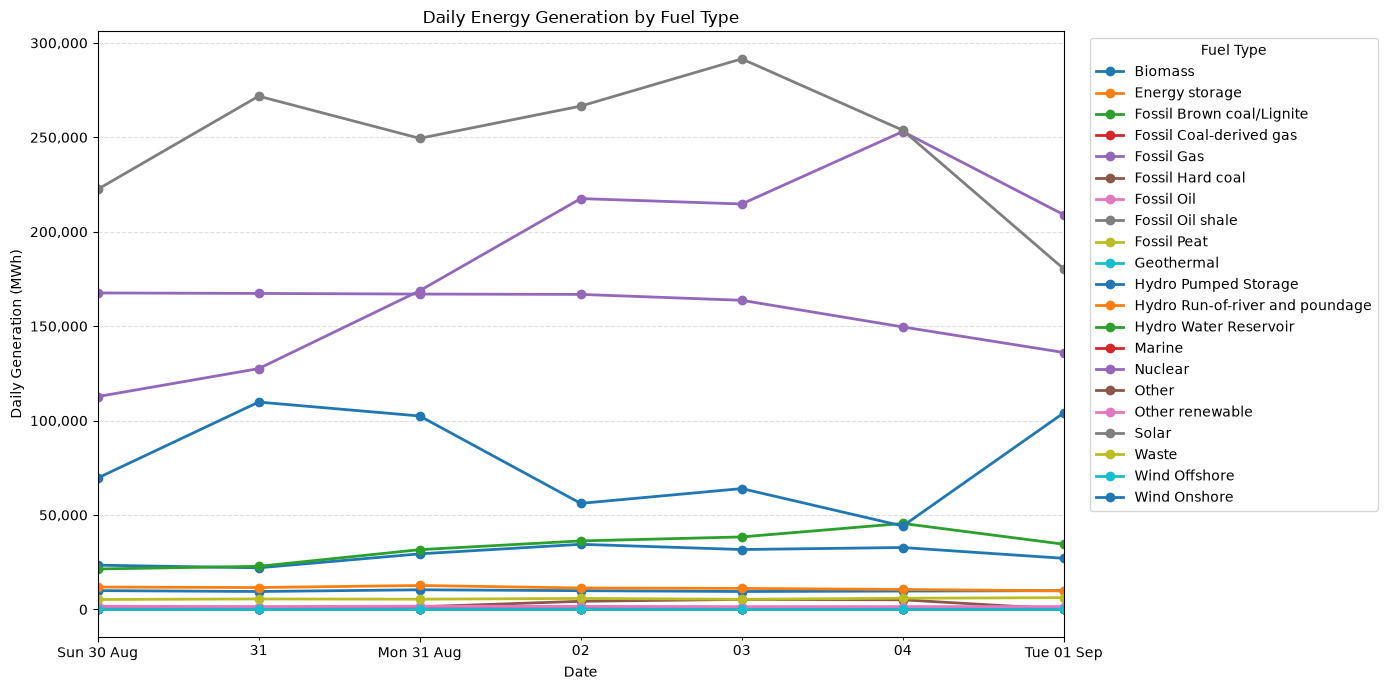

In [10]:
# Plot \Daily Energy Generation by Fuel Type/

ax = daily_generation_mwh.plot(
    figsize=(14, 7),
    marker="o",
    linewidth=2
)

ax.set_title("Daily Energy Generation by Fuel Type")


ax.set_xlabel("Date")
ax.set_xticklabels(
    daily_generation_mwh.index.strftime("%a %d %b"),
    rotation=0
)

ax.set_ylabel("Daily Generation (MWh)")
ax.yaxis.set_major_formatter( FuncFormatter(lambda x, pos: f"{x:,.0f}") )

ax.legend(title="Fuel Type", bbox_to_anchor=(1.02, 1), loc="upper left")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

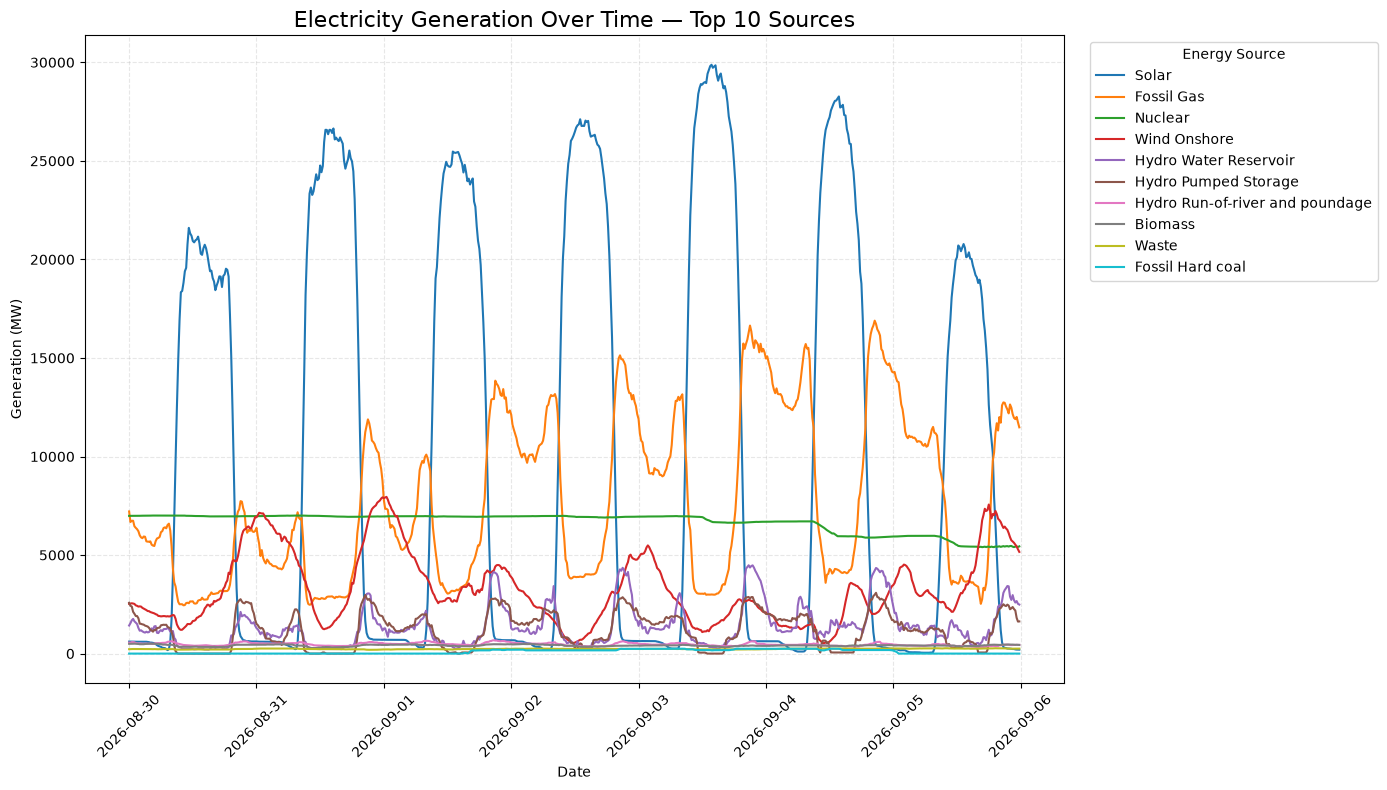

In [11]:
# Plot \Electricity Generation Over Time — Top N Sources/

generation_cols = [
    col for col in df.columns
    if col[1] == "Actual Aggregated"
]


# find the n largest generation sources
top_n = 10

top_sources = (
    df[generation_cols]
    .mean()
    .sort_values(ascending=False)
    .head(top_n)
    .index
)



# Plot 
fig, ax = plt.subplots(figsize=(14, 8))

for source in top_sources:
    ax.plot(
        df.index,
        df[source],
        label=source[0],
        linewidth=1.5
    )


ax.set_title(
    f"Electricity Generation Over Time — Top {top_n} Sources",
    fontsize=16,
)

ax.set_xlabel("Date")
ax.set_ylabel("Generation (MW)")

ax.legend(
    title="Energy Source",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(
    linestyle="--",
    alpha=0.3
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()